In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


2.20.0
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


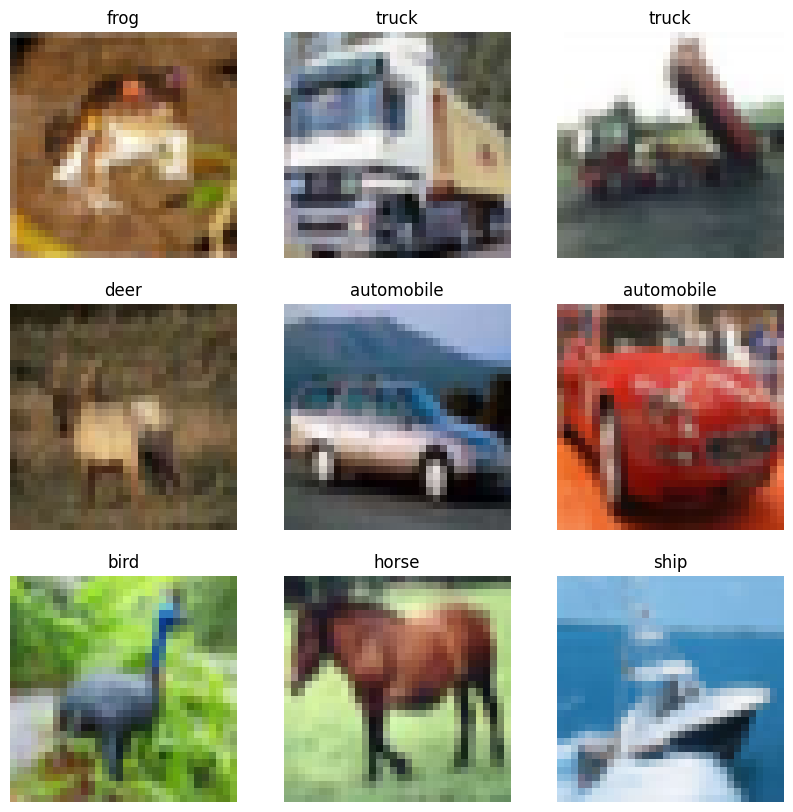

(10000, 32, 32, 3)
(10000, 1)
(2000, 32, 32, 3)
(2000, 1)


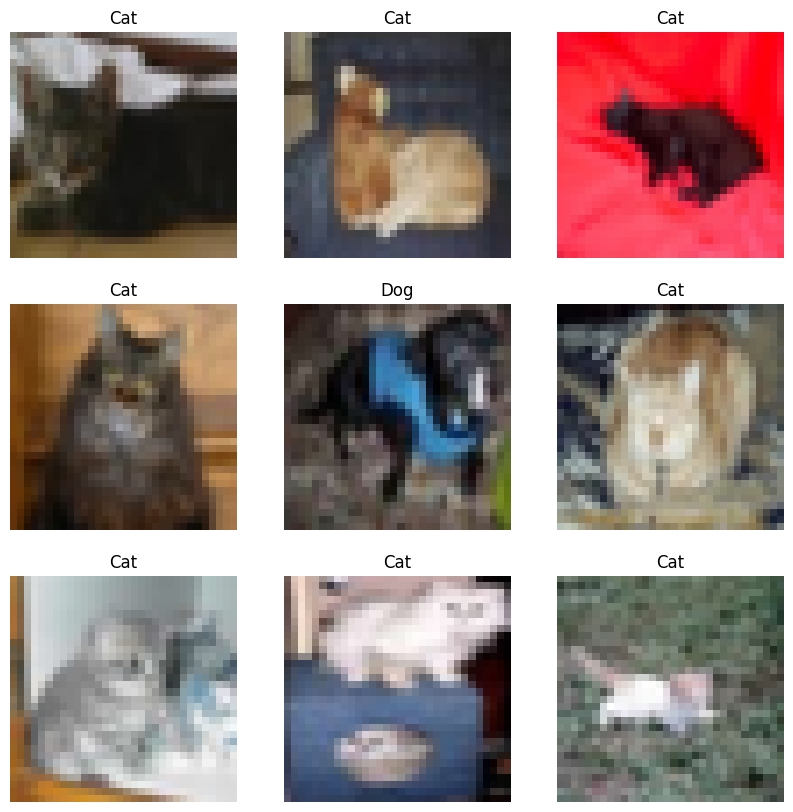

0.0
1.0
Training : (8500, 32, 32, 3)
Validation : (1500, 32, 32, 3)
Testing : (2000, 32, 32, 3)
(array([0, 1]), array([4250, 4250]))
(array([0, 1]), array([750, 750]))
(array([0, 1]), array([1000, 1000]))


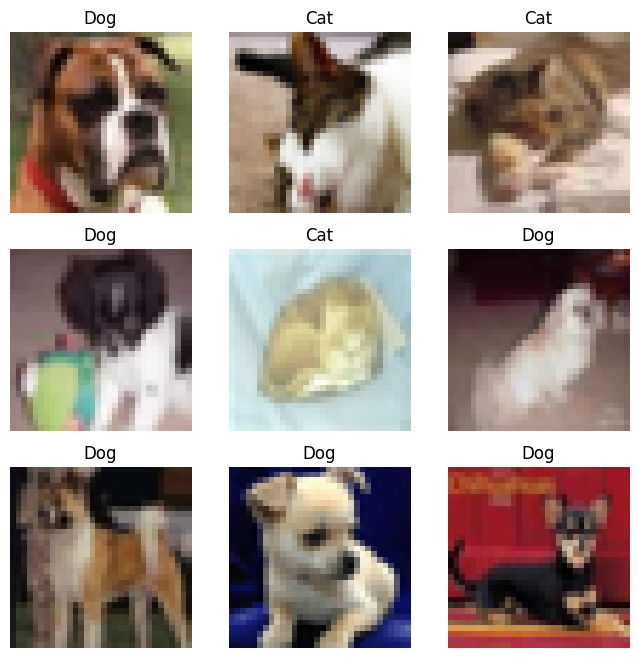

(8500, 32, 32, 3)
(8500, 1)
(1500, 32, 32, 3)
(1500, 1)
(2000, 32, 32, 3)
(2000, 1)


In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

print(tf.__version__)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

train_filter = np.where((y_train == 3) | (y_train == 5))[0]
test_filter = np.where((y_test == 3) | (y_test == 5))[0]

x_train = x_train[train_filter]
y_train = y_train[train_filter]

x_test = x_test[test_filter]
y_test = y_test[test_filter]

y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])

    if y_train[i]==0:
        plt.title("Cat")
    else:
        plt.title("Dog")

    plt.axis("off")

plt.show()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(x_train.min())
print(x_train.max())

from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print("Training :", x_train.shape)
print("Validation :", x_val.shape)
print("Testing :", x_test.shape)

print(np.unique(y_train, return_counts=True))
print(np.unique(y_val, return_counts=True))
print(np.unique(y_test, return_counts=True))

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(x_train[i])

    if y_train[i]==0:
        plt.title("Cat")
    else:
        plt.title("Dog")

    plt.axis("off")

plt.show()

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

print(x_train.shape)
print(y_train.shape)

print(x_val.shape)
print(y_val.shape)

print(x_test.shape)
print(y_test.shape)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.5398 - loss: 0.6876 - val_accuracy: 0.6287 - val_loss: 0.6562
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6241 - loss: 0.6464 - val_accuracy: 0.6713 - val_loss: 0.6055
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6632 - loss: 0.6210 - val_accuracy: 0.6660 - val_loss: 0.6009
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6793 - loss: 0.5998 - val_accuracy: 0.7007 - val_loss: 0.5761
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6986 - loss: 0.5774 - val_accuracy: 0.7127 - val_loss: 0.5521
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7081 - loss: 0.5635 - val_accuracy: 0.7307 - val_loss: 0.5285
Epoch 7/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7159 - loss: 0.5522 - val_accuracy: 0.7407 - val_loss: 0.5265
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7307 - loss: 0.5399 - val_accuracy:

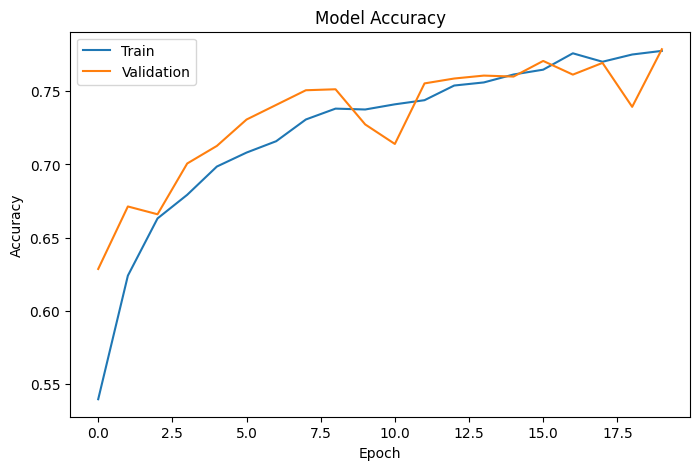

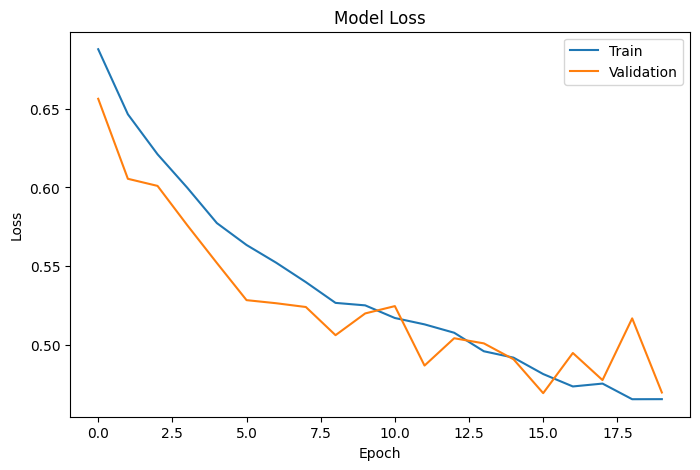

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[754 246]
 [224 776]]


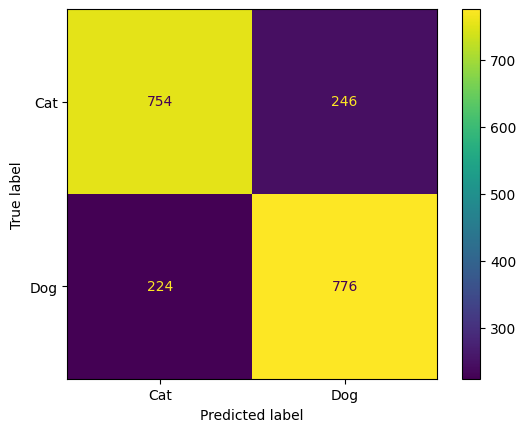

              precision    recall  f1-score   support

         Cat       0.77      0.75      0.76      1000
         Dog       0.76      0.78      0.77      1000

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.76      2000
weighted avg       0.77      0.77      0.76      2000



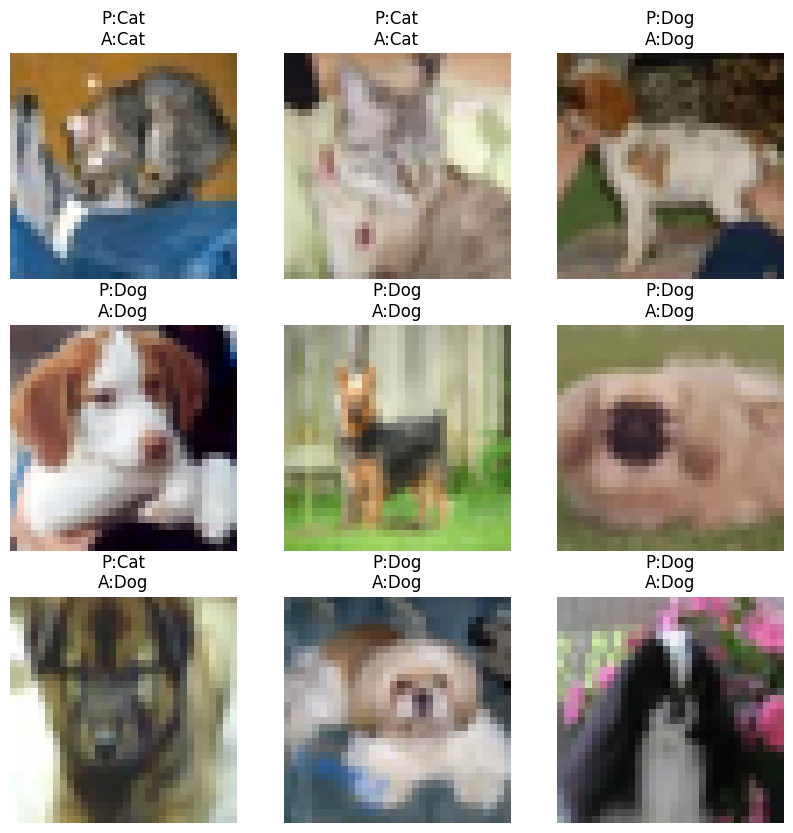

470


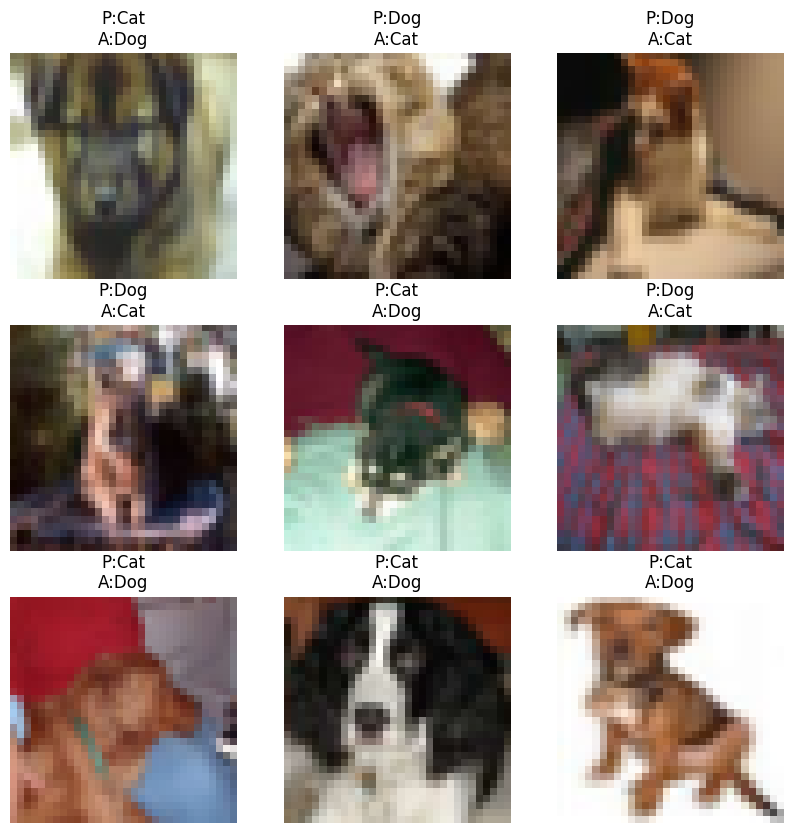

In [29]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    # Data augmentation
    data_augmentation,

    # CNN Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    # CNN Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # CNN Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Classifier
    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

Conv2D(32,(3,3))

MaxPooling2D(2,2)

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(

    x_train,
    y_train,

    validation_data=(x_val,y_val),

    epochs=20,

    batch_size=32,

    callbacks=[early_stop]

)

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()

from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(x_test)

y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

print(cm)

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat","Dog"]
)

disp.plot()

plt.show()

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Cat","Dog"]
    )
)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[i])

    pred = "Dog" if y_pred[i]==1 else "Cat"

    actual = "Dog" if y_test[i]==1 else "Cat"

    plt.title(f"P:{pred}\nA:{actual}")

    plt.axis("off")

plt.show()

wrong = np.where(y_pred.flatten() != y_test.flatten())[0]

print(len(wrong))

plt.figure(figsize=(10,10))

for i in range(9):

    idx = wrong[i]

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[idx])

    pred = "Dog" if y_pred[idx]==1 else "Cat"

    actual = "Dog" if y_test[idx]==1 else "Cat"

    plt.title(f"P:{pred}\nA:{actual}")

    plt.axis("off")

plt.show()